This notebook contains the code to generate Figure 3 of "Wasting is essential: cachexia is caused by a prolonged wound healing mechanism" and an explanation of the figure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reaction_flask import ReactionFlask

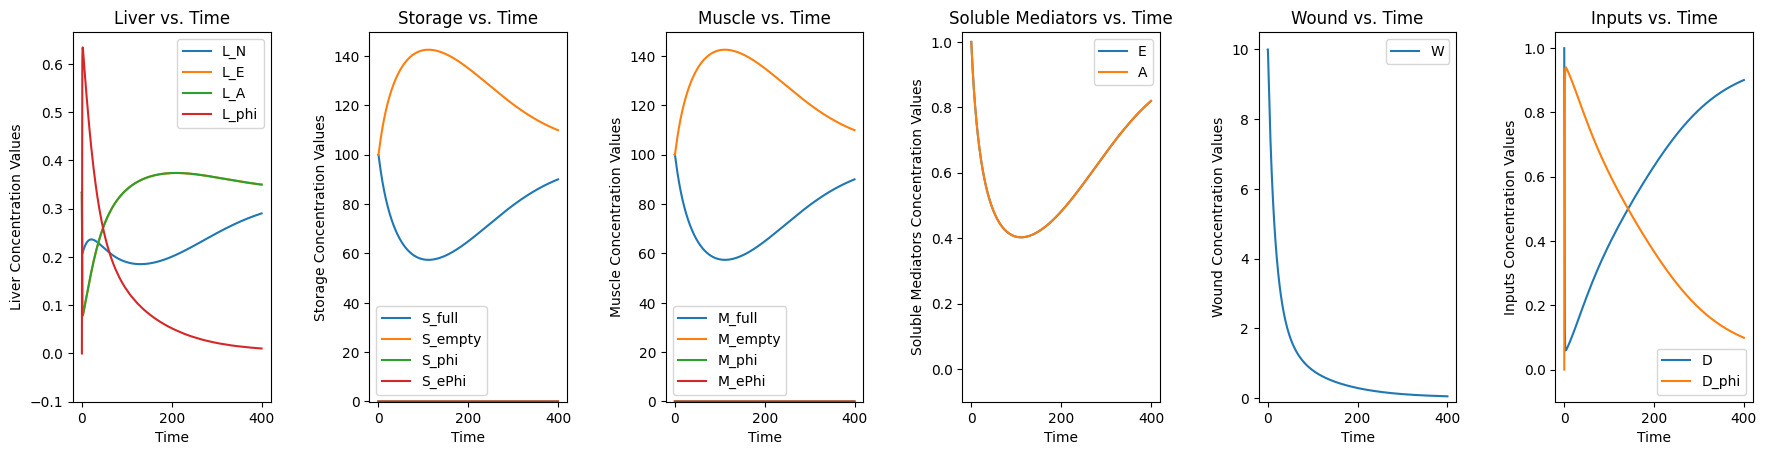

-0.24804730738587838
Final value of W: 0.055331432472386886


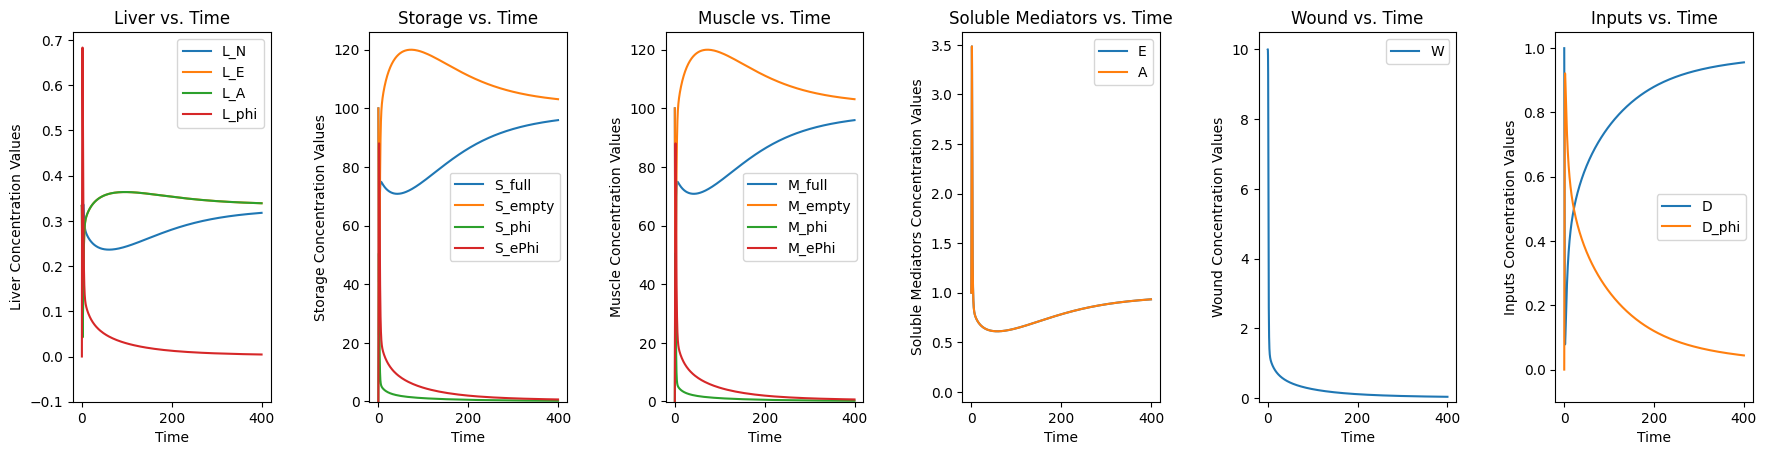

0.11457752334785809
Final value of W: 0.041171666775208456


In [31]:
initWound = 10

diet = 1

rxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

rxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

timeValuesList = []

woundValsVsTime = []
weightValsVsTime = []
nutrientsVsTime = []

for x in range(2):

  if(x == 0):
    inflammationInducedWasting = False
  elif (x == 1):
    inflammationInducedWasting = True

  #
  rxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

  #
  rxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

  #
  rxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

  #
  rxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

  #
  rxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

  #
  rxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

  #
  rxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

  #
  rxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

  #
  rxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

  #
  rxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

  #
  rxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

  #
  rxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    rxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
  else:
    #This allows S_full to continue acting as an inflammation sink without changing state
    rxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    rxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
  else:
    #This allows S_empty to continue acting as an inflammation sink without changing state
    rxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

  #
  rxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

  #
  rxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

  #
  rxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

  #
  rxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

  #
  rxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  rxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

  #
  rxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

  #
  rxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

  #
  rxnFlask.addReaction("Reaction 23: W -> W + phi", 75, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

  #
  rxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

  #
  rxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  rxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  rxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

  #
  rxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    rxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
  else:
    #This allows M_full to continue acting as an inflammation sink while not changing state
    rxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
    rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 0, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})
    
  else:
    #This allows M_empty to continue acting as an inflammation sink while not changing state
    #rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 0, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
    rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

  #
  rxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

  #
  rxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

  #
  rxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

  #
  rxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

  #
  rxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})


  rxnFlask.runSystem(400)

  rxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

  timeValues = rxnFlask.latestSimulationOutput["t"]

  localWeightDropValues = (46 * 2 - rxnFlask.latestSimulationOutput["y"][7] - rxnFlask.latestSimulationOutput["y"][11])

  print(np.max(localWeightDropValues) / (46 * 2))

  #print(rxnFlask.latestSimulationOutput["t"])

  print(f"Final value of W: {rxnFlask.getFinalValueOfVariable('W')}")

  rxnFlask.resetInitialCondition()

  timeValuesList.append(timeValues)
  woundValsVsTime.append(rxnFlask.latestSimulationOutput["y"][0])
  weightValsVsTime.append(2 * rxnFlask.latestSimulationOutput["y"][7])
  nutrientsVsTime.append(rxnFlask.latestSimulationOutput["y"][16])

In [36]:
#1. Get boolean mask of finalWoundValues, <= 10% of initWound
def calculateWoundHealingTime(timeValues, woundValues, threshold):
  #initWound = woundValues[0], correct?
  healedWound = np.where(woundValues <= threshold * woundValues[0])[0]
  try:
    healedWoundIndex = healedWound[0]
  except(IndexError):
    #This ensures that, if the wound never was healed to the threshold, it
    #automatically reports the longest time
    return timeValues[-1]

  healedWoundTime = timeValues[healedWoundIndex]
  return healedWoundTime


In [37]:
calculateWoundHealingTime(timeValuesList[1], woundValsVsTime[1], 0.1)

np.float64(8.688238047700054)